# $\mu s$ALEX with $\mathbf{H^{2}MM}$

[Harris et. al 2022](https://doi.org/10.1038/s41467-022-28632-x) introduced the idea of a "shift"
to allow mpH<sup>2</sup>MM analysis on $\mu s$ALEX data. 
Files/directories available on [zenodo](https://doi.org/10.5281/zenodo.4671392).

This notebook is meant to demonstate the same analysis as done in the 
`"H2MM-Multidimensional-Example_Apo_and_Actin-YopO-100usalternation-decays.ipynb"`
notebook of previous versions.

It is not shown as an adaptation with the old code in comments because
it has been re-strucured such that it is more easily understood as is.

The notebooks based on HP3 will be more useful in understanding how to translate from FRETBursts.

## Initial imports

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import smfbursts as smf
smf.rcParams['record'] = True
import H2MM_C as hm
import H2MMbursts as bhm

## Loading Data

One coding choice you will have to make when loading different data sets, is how to organize them.
This is the choice of the Python programer, and will use Python features.

For small numbers of datasets, creating a new variable for each is often the easiest.
However, as the number grows larger, you may want to create a dictionary, 
which makes iterating over all data sets easier.

Here we will demonstrate the dictionary approach.

The data was aquired in 10 minute segments, 
each each folder represents a single measurement, 
each file is a 10 minute segment of that measuremnt.

In [2]:
load_dirs = {'apo':'data/Apo_50us ALEX_1hr/',
             'holo':'data/Holo 60uM actin_0.2mM ATP_0.2mM CaCl2_50usec_1.5hr/',}

raws = {key:smf.loadraw.load_dir(data_dir, finalizer='raw') 
        for key, data_dir in load_dirs.items()}

Now we can regularize each.

In [3]:
datas = {key:smf.photonHDF5.regularize_dets(raw) for key, raw in raws.items()}

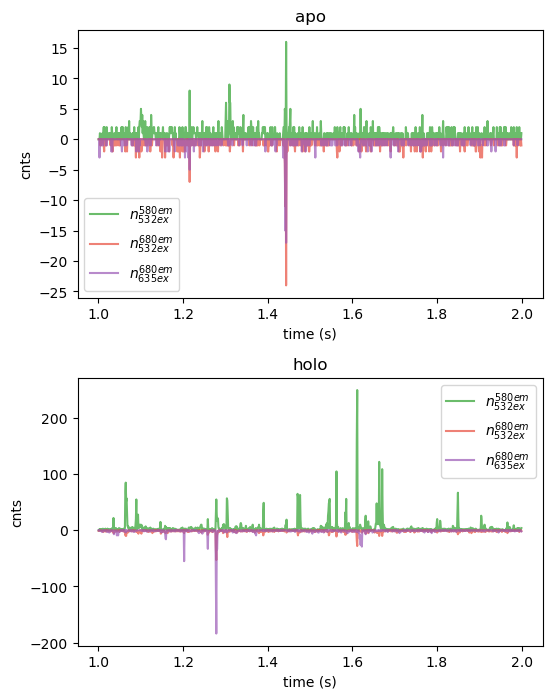

In [4]:
fig, axs = plt.subplots(len(datas), 1, figsize=(6,4*len(datas)), gridspec_kw={'hspace':0.3})
for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.timetrace(data.datas[0], ax=ax, 
                       streams=smf.fretfactory.ALEXdefaults.streams[1:],
                       stream_kwargs=smf.fretfactory.ALEXdefaults.stream_colors[1:],
                       direction=(1,-1, -1), alpha=0.7, tmin=1.0, tmax=2.0)
    ax.set_title(key)

## Burst Isolation

### Background analysis

Now we need to compute the background.

In smfBursts, data is separated from instructions, so we will start by defining the background instructions.

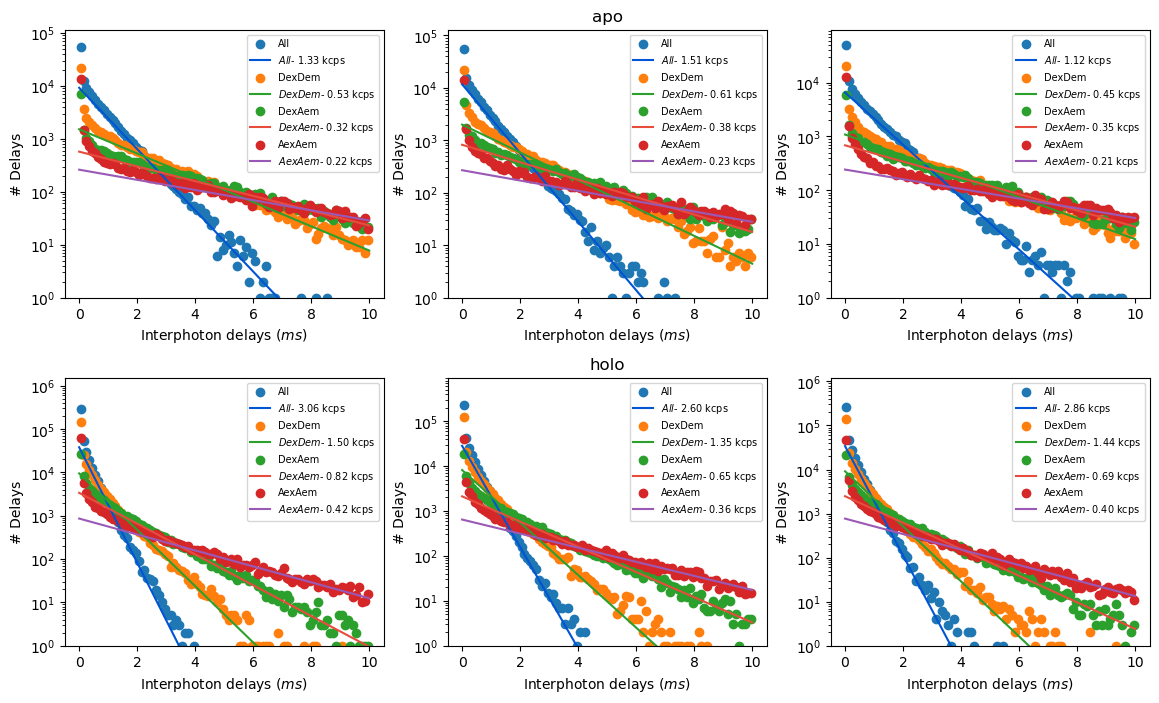

In [5]:
bg = smf.fretfactory.make_bg(datas['holo'], func=smf.bg.exp_mlefit, tail_min=5e-4, auto_threshold=True, F_bg=1.7)

fig, axs = plt.subplots(len(datas), 3, figsize=(14, 4*len(datas)), gridspec_kw={'hspace':0.3})
for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.hist_interphoton(data.datas[0], bg['bg'], 0, 
                              ax=ax[0], streams=smf.fretfactory.ALEXdefaults.streams,
                              labels=smf.fretfactory.ALEXdefaults.stream_labels,
                              fit_streams_kwargs=smf.fretfactory.ALEXdefaults.stream_colors, 
                              legend_kwargs={'fontsize':7})
    smf.plot.hist_interphoton(data.datas[len(data.datas)//2], bg['bg'], 0, 
                              ax=ax[1], streams=smf.fretfactory.ALEXdefaults.streams,
                              labels=smf.fretfactory.ALEXdefaults.stream_labels,
                              fit_streams_kwargs=smf.fretfactory.ALEXdefaults.stream_colors,
                              legend_kwargs={'fontsize':7})
    smf.plot.hist_interphoton(data.datas[-1], bg['bg'], 0, 
                              ax=ax[2], streams=smf.fretfactory.ALEXdefaults.streams,
                              labels=smf.fretfactory.ALEXdefaults.stream_labels,
                              fit_streams_kwargs=smf.fretfactory.ALEXdefaults.stream_colors, 
                              legend_kwargs={'fontsize':7})
    ax[0].set_ylim(1)
    ax[1].set_ylim(1)
    ax[2].set_ylim(1)
    ax[1].set_title(key)

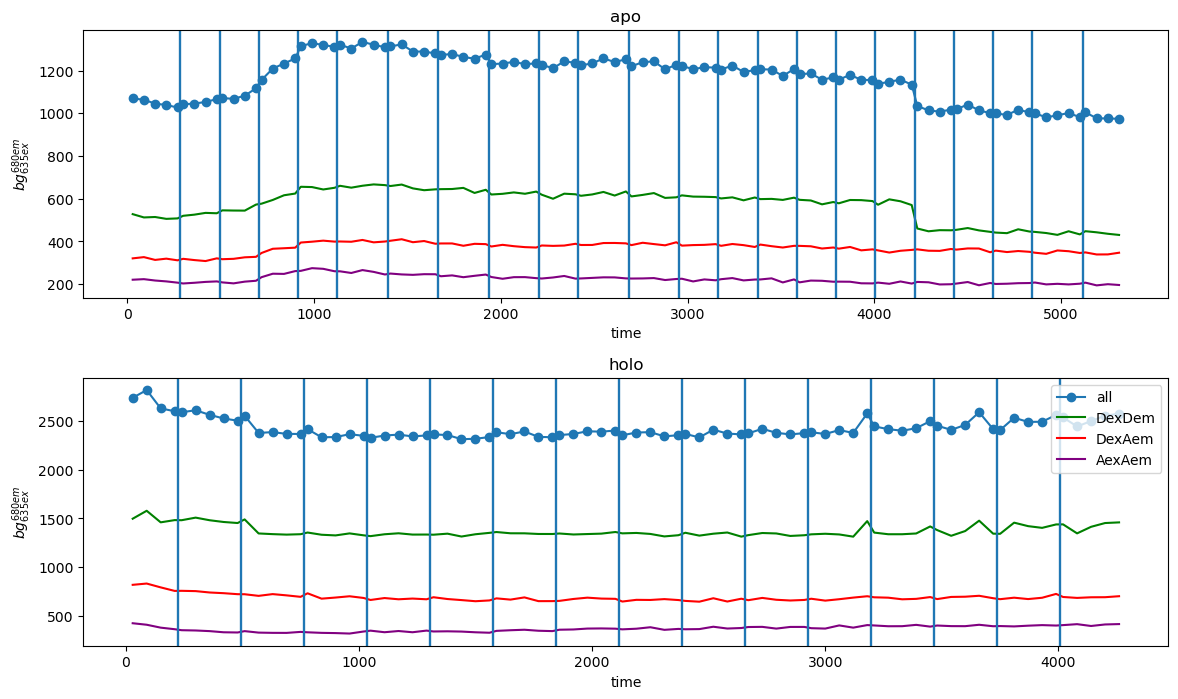

In [6]:
fig, axs = plt.subplots(len(datas), 1, figsize=(14, 4*len(datas)), gridspec_kw={'hspace':0.3})

for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.time_plot(data, bg['BgAll'], ax=ax, marker='o', divlines=True, label='all')
    smf.plot.time_plot(data, bg['BgDD'], ax=ax, divlines=True, c='g', label='DexDem')
    smf.plot.time_plot(data, bg['BgDA'], ax=ax, divlines=True, c='r', label='DexAem')
    smf.plot.time_plot(data, bg['BgAA'], ax=ax, divlines=True, c='purple', label='AexAem')
    ax.set_title(key)
axs[-1].legend()

In the apo data we see a sudden increase in the background.

If you count the number of divisions, you will see this as the last 12 files.
So, in teh cell below, we recreate a `smf.PhotonDataList` excluding the last 12 sections.

In [7]:
datas['apo'] = smf.PhotonDataList(datas['apo'].datas[:-12])

Below we compare the timetraces of a 1 second segment from each dataset,
using the `smf.plot.timetrace` function, as a "spot-check" that the data looks reasonable.

Note however that as bursts are the result of diffusion, it is a stochastic process, 
and therefore any signle segemnt may be rather different from another.

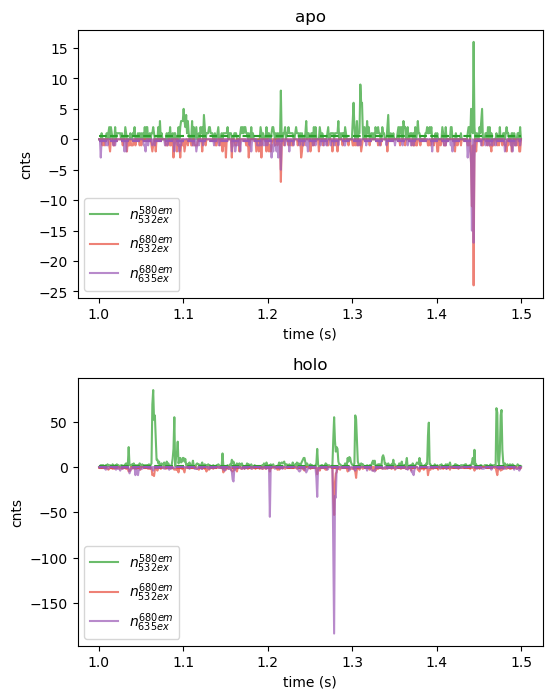

In [8]:
fig, axs = plt.subplots(len(datas), 1, figsize=(6,4*len(datas)), gridspec_kw={'hspace':0.3})
for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.timetrace(data.datas[0], ax=ax, bg=bg['bg'],
                       streams=smf.fretfactory.ALEXdefaults.streams[1:],
                       stream_kwargs=smf.fretfactory.ALEXdefaults.stream_colors[1:],
                       bg_labels=False, bg_kwargs={'ls':'--'},
                       direction=(1,-1, -1), alpha=0.7, tmin=1.0, tmax=1.5)
    ax.set_title(key)

### Burst Search

#### All Channel Burst Search

First, let's define an ACBS-style burst search,
this means searching over all "active" streams.

Note also that we set the `nbva=5` so we can be consistent.
If you wish to change the bva chunck size, change this variable.

In [9]:
nbva = 5
# raw acbs burst search
acbs = smf.fretfactory.make_burst_search(bg=bg['bg'], m=10, F=6.0, 
                                         streams=smf.PhSel('0ex_1ex1em'),
                                         nbva=nbva)
# gate for ACBS, again over all photons
gacbs = smf.make_geq_gate(acbs['NphActive_bg'], 100)
# makes all params have this gate by default, 
# avoid needing to specify gate on all plots etc.
acbs = smf.fretfactory.apply_gate(acbs, gacbs)

Calling timetrace again, this times setting `bg=acbs['bursts']` lets us see
the *background* threshold (*not* the gate) for bursts.

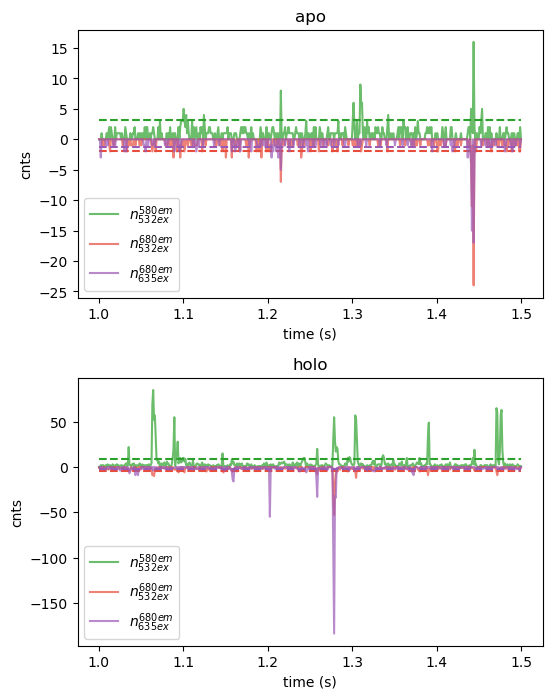

In [10]:
fig, axs = plt.subplots(len(datas), 1, figsize=(6,4*len(datas)), gridspec_kw={'hspace':0.3})
for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.timetrace(data.datas[0], ax=ax, bg=acbs['bursts'],
                       streams=smf.fretfactory.ALEXdefaults.streams[1:],
                       stream_kwargs=smf.fretfactory.ALEXdefaults.stream_colors[1:],
                       bg_labels=False, bg_kwargs={'ls':'--'},
                       direction=(1,-1, -1), alpha=0.7, tmin=1.0, tmax=1.5)
    ax.set_title(key)

Now to check the data, we will plot 3 of the 10 minute sections isn separte plots,
this lets us spot-check that they are all roughly identical.
If there is a big difference, (in this dataset there aren't),
then it would be best to check all sub-datasets, and remove those, similar to 
how the datsets with high background were removed before.

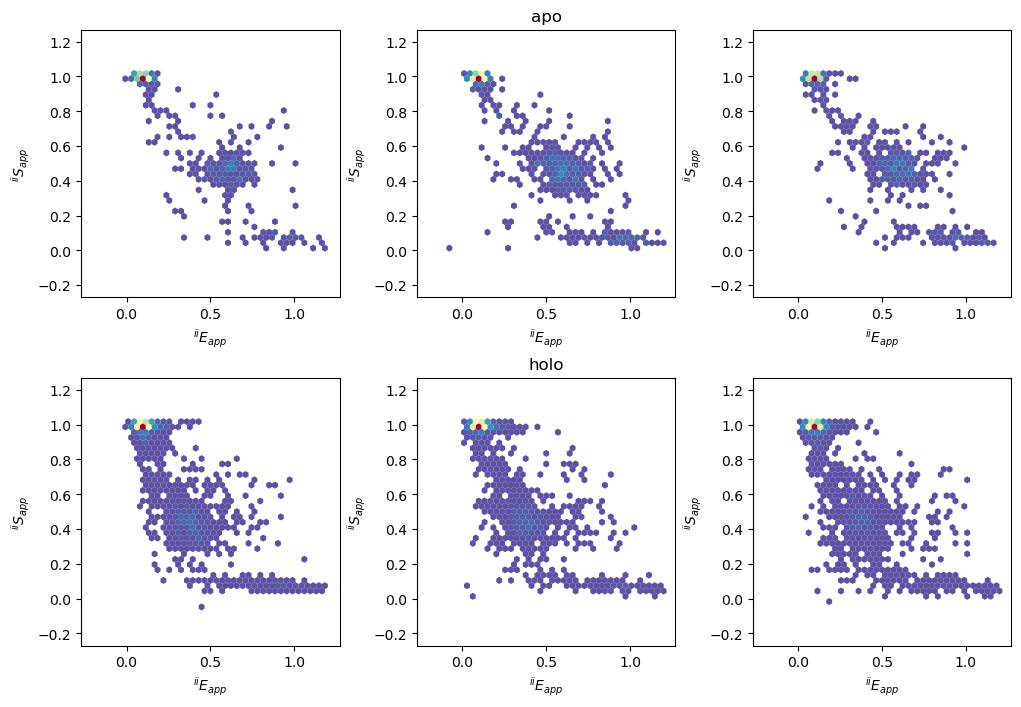

In [11]:
fig, axs = plt.subplots(len(datas), 3, figsize=(12,4*len(datas)), 
                        gridspec_kw={'hspace':0.3, 'wspace':0.3})
for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.hexbin(data.datas[0], acbs['E_bg'], acbs['S_bg'], ax=ax[0], 
                    cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
    smf.plot.hexbin(data.datas[len(data.datas)//2], acbs['E_bg'], acbs['S_bg'], 
                    cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'], ax=ax[1])
    smf.plot.hexbin(data.datas[-1], acbs['E_bg'], acbs['S_bg'], 
                    cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'], ax=ax[2])
    ax[1].set_title(key)

We can also plot all of the datasets together, to see the end result of the histogram.

Text(0.5, 0.98, 'acbs')

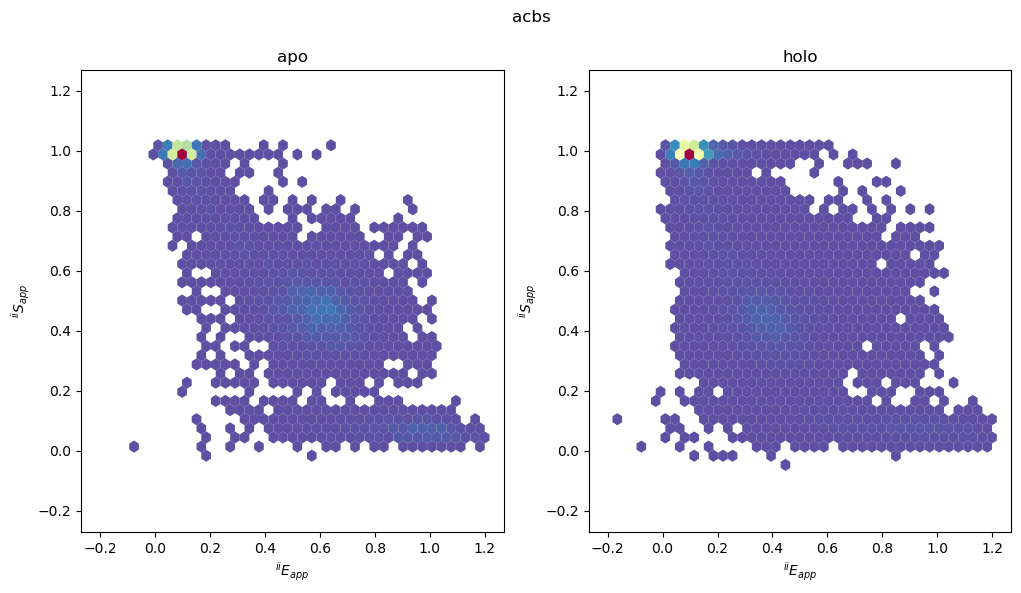

In [12]:
fig, axs = plt.subplots(1,len(datas), figsize=(len(datas)*6,6), 
                        gridspec_kw={'hspace':0.3})
for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.hexbin(data, acbs['E_bg'], acbs['S_bg'], ax=ax, cmap='Spectral_r',
                    **smf.fretfactory.ALEXdefaults['hexbin'])
    ax.set_title(key)
fig.suptitle('acbs')

#### Dual Channel Burst Search

It is also a good idea to check the DCBS, specifying 2 streams:
Dex and AexAem, which will be "and-gated" together.

In [13]:
# make DCBS burst search
dcbs = smf.fretfactory.make_burst_search(bg=bg['bg'], m=10, F=6.0, 
                                         streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')),
                                         nbva=nbva)
# Make a gate, because already using DCSB, we can set lower thresholds,
# set threshold for both Dex and AexAem gate
gdcbs = smf.make_geq_gate(dcbs['NphDex_bg'], 30) & smf.make_geq_gate(dcbs['NphAA_bg'], 30)
# apply gate to all params/columns in dict
dcbs = smf.fretfactory.apply_gate(dcbs, gdcbs)

Text(0.5, 0.98, 'acbs')

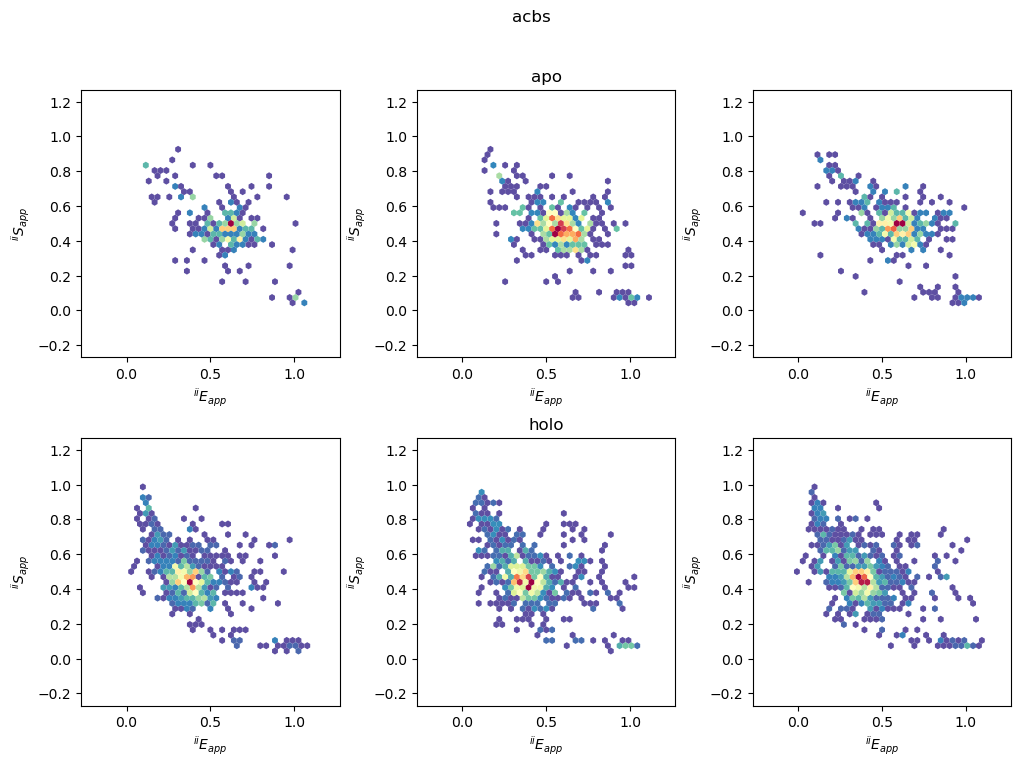

In [14]:
fig, axs = plt.subplots(len(datas), 3, 
                        figsize=(12,4*len(datas)), 
                        gridspec_kw={'hspace':0.3, 'wspace':0.3})

for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.hexbin(data.datas[0], dcbs['E_bg'], dcbs['S_bg'], ax=ax[0], 
                    cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
    smf.plot.hexbin(data.datas[len(data.datas)//2], dcbs['E_bg'], dcbs['S_bg'], 
                    ax=ax[1], 
                    cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
    smf.plot.hexbin(data.datas[-1], dcbs['E_bg'], dcbs['S_bg'], ax=ax[2], 
                    cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
    ax[1].set_title(key)
fig.suptitle('acbs')

And plot the composite histogram.

Text(0.5, 0.98, 'dcbs')

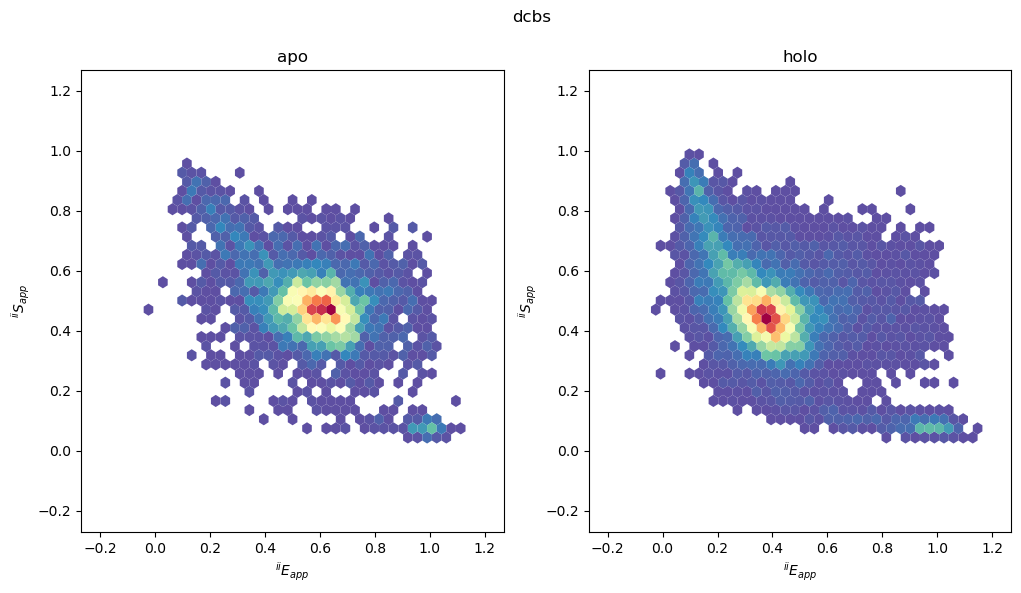

In [15]:
fig, axs = plt.subplots(1,len(datas), 
                        figsize=(len(datas)*6,6), 
                        gridspec_kw={'hspace':0.3})

for ax, (key, data) in zip(axs, datas.items()):
    smf.plot.hexbin(data, dcbs['E_bg'], dcbs['S_bg'], ax=ax, cmap='Spectral_r',
                    **smf.fretfactory.ALEXdefaults['hexbin'])
    ax.set_title(key)

fig.suptitle("dcbs")

### BVA analysis

Prior to $\mathbf{H^{2}MM}$ it is good to use BVA as a qualitative check.
If within burst dynamics are occuring, 
then the mean BVA should be elevated above the static FRET line.

Text(0.5, 0.98, 'ACBS')

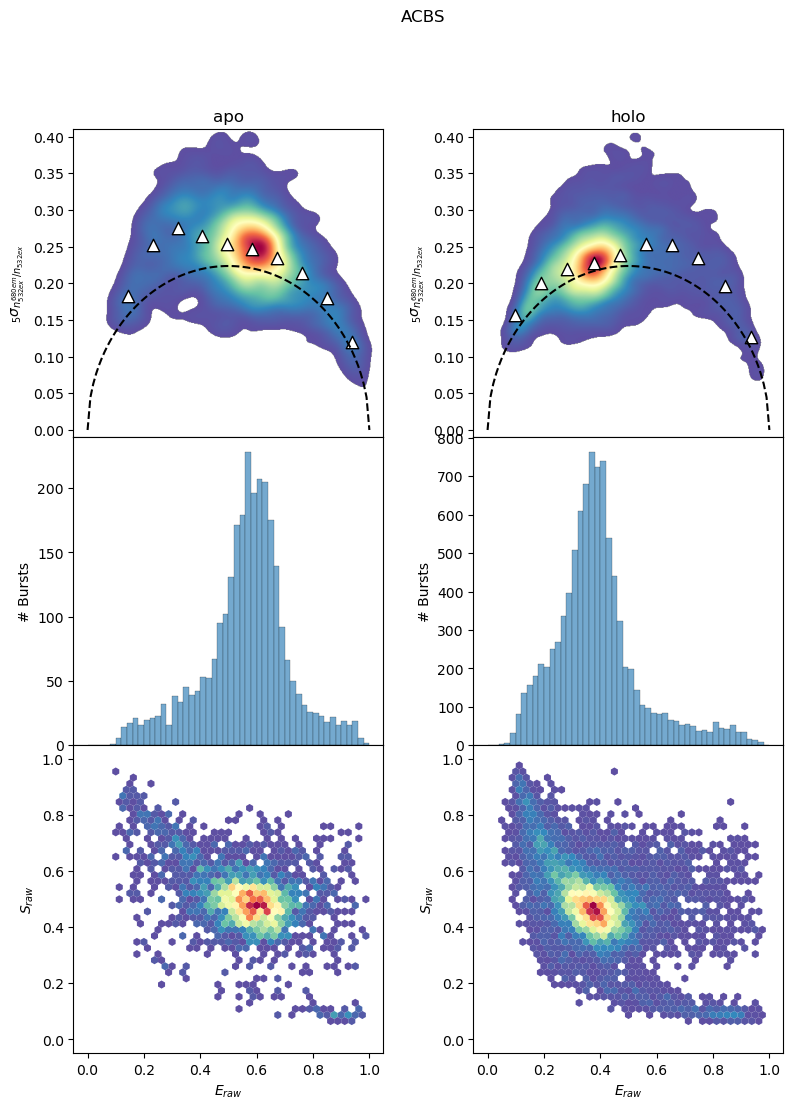

In [16]:
# arrays for default static BVA line
x_t = np.linspace(0,1,100)
y_t = np.sqrt((1-x_t)*x_t/nbva)

# gate removing bursts with too few photons in excitation channels
gacbs_fret = acbs['bursts'].base_gate & smf.make_geq_gate(acbs['NphAA_bg'], 50.0) & smf.make_geq_gate(acbs['NphDex_bg'], 50.0)

# plots
fig = plt.figure(figsize=(len(datas)*4, 12))
subfigs = fig.subfigures(1, len(datas))

for sfig, (key, data) in zip(subfigs, datas.items()):
    ax = sfig.subplots(3,1, gridspec_kw={'hspace':0.0}, sharex=True)
    ax[0].set_title(key)
    smf.plot.kdeplot(data, acbs['E_raw'], acbs[f'BVA{nbva}'], 
                     ax=ax[0], gate=gacbs_fret, 
                     cmap='Spectral_r', thresh=0.01)
    smf.plot.scatter_meaninterval(data, acbs['E_raw'], acbs[f'BVA{nbva}'],
                                  gate=gacbs_fret, ax=ax[0], 
                                  marker='^', c='w', ec='k', s=80)
    ax[0].plot(x_t, y_t, c='k', ls='--')
    ax[0].set_xlim([-0.05, 1.05])
    ax[0].set_ylim([-0.01, 0.41])
    smf.plot.hist_bar(data, acbs['E_raw'], ax=ax[1], gate=gacbs_fret,
                      **smf.fretfactory.ALEXdefaults['histbar',('bins', 'raw_ratio_bins')])
    smf.plot.hexbin(data, acbs['E_raw'], acbs['S_raw'], 
                    gate=gacbs_fret, ax=ax[2], cmap='Spectral_r',
                    **smf.fretfactory.ALEXdefaults['hexbinraw'])
fig.suptitle('ACBS')

Text(0.5, 0.98, 'DCBS')

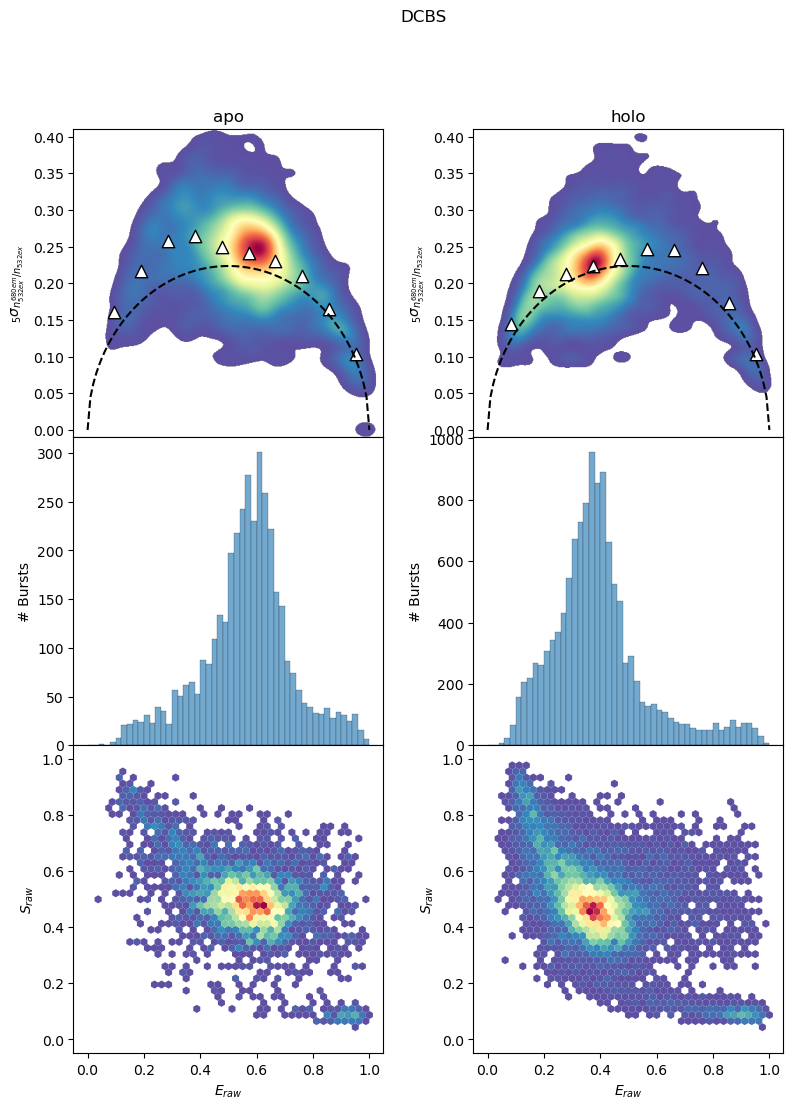

In [17]:
# plots
fig = plt.figure(figsize=(len(datas)*4, 12))
subfigs = fig.subfigures(1, len(datas))

for sfig, (key, data) in zip(subfigs, datas.items()):
    ax = sfig.subplots(3,1, gridspec_kw={'hspace':0.0}, sharex=True)
    ax[0].set_title(key)
    smf.plot.kdeplot(data, dcbs['E_raw'], dcbs[f'BVA{nbva}'], ax=ax[0], 
                     cmap='Spectral_r', thresh=0.01)
    smf.plot.scatter_meaninterval(data, dcbs['E_raw'], dcbs[f'BVA{nbva}'], 
                                  ax=ax[0], marker='^', c='w', ec='k', s=80)
    ax[0].plot(x_t, y_t, c='k', ls='--')
    ax[0].set_xlim([-0.05, 1.05])
    ax[0].set_ylim([-0.01, 0.41])
    smf.plot.hist_bar(data, dcbs['E_raw'], ax=ax[1],
                      **smf.fretfactory.ALEXdefaults['histbar',('bins', 'raw_ratio_bins')])
    smf.plot.hexbin(data, dcbs['E_raw'], dcbs['S_raw'], 
                    ax=ax[2], cmap='Spectral_r',
                    **smf.fretfactory.ALEXdefaults['hexbinraw'])
fig.suptitle('DCBS')

## $\mathbf{H^{2}MM}$ analysis

### Single Parameter $\mathbf{H^{2}MM}$

Because of the alternation period, it is best to analyze the data in 2 ways:
1. With just Donor excitation streams, for single paramter $\mathbf{H^{2}MM}$
   For this we use the normal `bhm.StatePath` table as the base,
   because no shift is necessary
2. $\mathbf{H^{2}MM}$ with shift.
   In this analysis, we must ise the `bhm.usAlexStatePath` table instead,
   as it allows use to specify the base.

In [18]:
spstreams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'))

gacbs_sp = gacbs_fret & smf.make_range_gate(acbs['E_bg'], 0.25, 0.7)
gdcbs_sp = gdcbs & smf.make_range_gate(dcbs['E_bg'], 0.25, 0.7)

statepaths = dict()
dwells = dict()

for key, data in datas.items():
    # perform optimization
    k = f'{key}.acbs.sp'
    statepaths[k] = bhm.StatePath.optimize_models(data, acbs['bursts'], gate=gacbs_sp,
                                                  streams=spstreams, conv_crit='BICph',
                                                  thresh=0.005)
    # generate dwell based parameters/columns
    dwells[k] = [bhm.fretfactory.make_dwell_dict(statepath) 
                 for statepath in statepaths[k]]
    
    k = f'{key}.dcbs.sp'
    statepaths[k] = bhm.StatePath.optimize_models(data, dcbs['bursts'], gate=gdcbs_sp,
                                                  streams=spstreams, conv_crit='BICph',
                                                  thresh=0.005)
    # generate dwell based parameters/columns
    dwells[k] = [bhm.fretfactory.make_dwell_dict(statepath) 
                 for statepath in statepaths[k]]

The model converged after 1 iterations
The model converged after 256 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
The model converged after 1 iterations
The model converged after 273 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
The model converged after 2 iterations
The model converged after 355 iterations
The model converged after 288 iterations
Optimization reached maximum number of iterations
The model converged after 1 iterations
The model converged after 389 iterations
The model converged after 284 iterations
Optimization reached maximum number of iterations


To determine the ideal model, we compare the statistical discriminators:

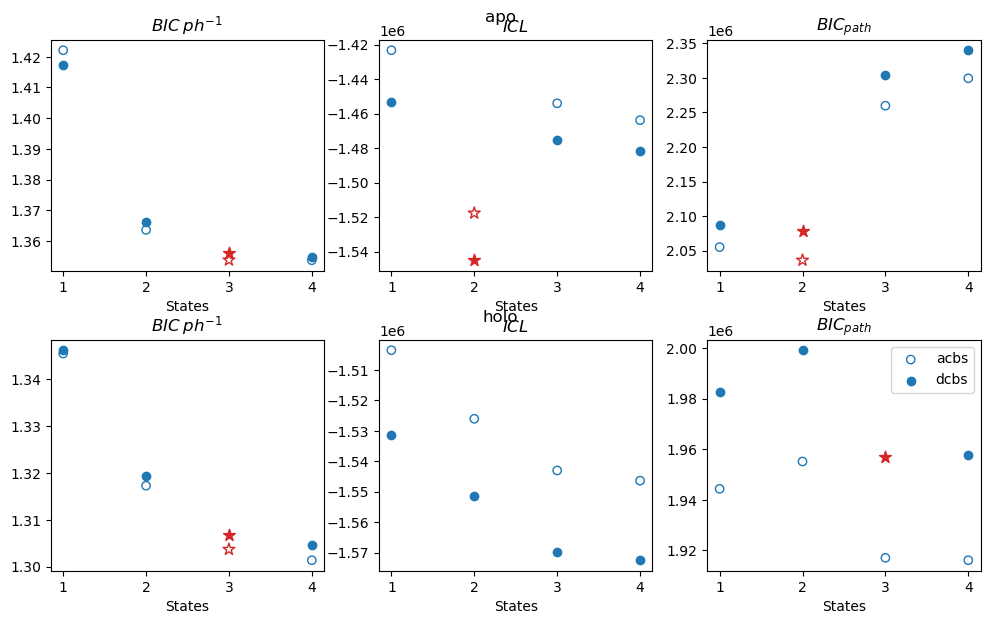

In [19]:
acbs_kwargs = {'c':'None', 'ec':'#1f77b4', 'highlight_kwargs':{'c':'None', 'ec':'#d62728'}}
dcbs_kwargs = {'c':'#1f77b4', 'highlight_kwargs':{'c':'#d62728'}}

fig = plt.figure(figsize=(12, 3*len(datas)))
subfigs = fig.subfigures(len(datas),1)

for sfig, key in zip(subfigs, datas.keys()):
    ax = sfig.subplots(1,3)
    # plot acbs
    k = f'{key}.acbs.sp'
    statepath = statepaths[k]
    bhm.plot.scatter_BICph(data, statepath, ax=ax[0], thresh=0.005, **acbs_kwargs)
    bhm.plot.scatter_ICL(data, statepath, ax=ax[1], **acbs_kwargs)
    bhm.plot.scatter_pathBIC(data, statepath, ax=ax[2], label='acbs', **acbs_kwargs)
    # plot dcbs
    k = f'{key}.dcbs.sp'
    statepath = statepaths[k]
    bhm.plot.scatter_BICph(data, statepath, ax=ax[0], thresh=0.005, **dcbs_kwargs)
    bhm.plot.scatter_ICL(data, statepath, ax=ax[1], **dcbs_kwargs)
    bhm.plot.scatter_pathBIC(data, statepath, ax=ax[2], label='dcbs', **dcbs_kwargs)
    sfig.suptitle(key)
ax[-1].legend()

The ACBS results suggest either 2 or 3 states for apo, and 3 states for holo.
We will plot the 2 and 3 states for the holo as well so that the plot doesn't have a gap.

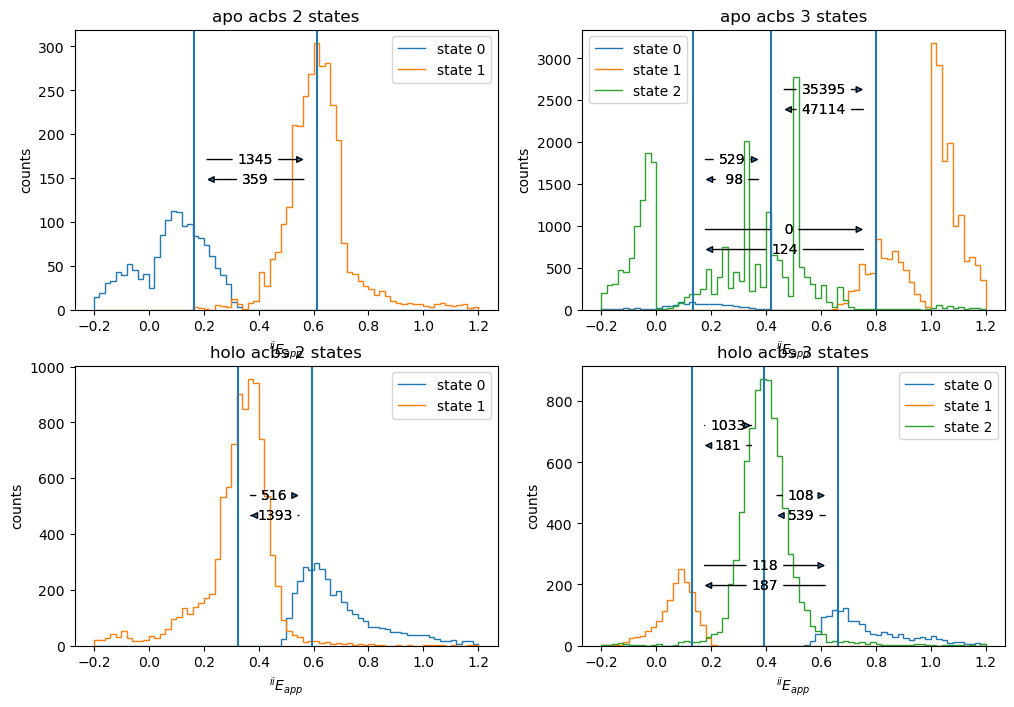

In [20]:
kf = '%s.acbs.sp'
states = {'apo':(2, 3), 'holo':(2,3)} # states to check

ml = max(len(val) for val in states.values())
fig, ax = plt.subplots(len(datas), ml, figsize=(6*ml, 4*len(datas)))

for i, (key, data) in enumerate(datas.items()):
    k = kf % key
    for j, state in enumerate(states[key]):
        for s in range(state):
            g = smf.make_isin_gate(dwells[k][state-1]['State'], s)
            smf.plot.hist_stair(data, dwells[k][state-1]['E_bg'], 
                                gate=g, ax=ax[i,j],
                                bins=smf.fretfactory.ALEXdefaults['ratio_bins'],
                                label=f'state {s}')
        bhm.plot.hist_model(dwells[k][state-1]['E_raw'], data=data, ax=ax[i,j])
        bhm.plot.hist_model_trans_arrows(dwells[k][state-1]['E_raw'], data=data, ax=ax[i,j])
        ax[i,j].legend()
        ax[i,j].set_title(f'{key} acbs {state} states')

In H2MMbursts, the models always have states ordered from least common to most common.
For display however, we usually want a give conformation to have the same color.
For this, we give names to the states, in the order found in the model,
and then provide a sorting index to map the model order to the order we want them displayed.

Note that is step is only necessary for display with consistent colors, and labels for states.
The values in these dictionaries will be used only when we reach the final display of the results.

In [21]:
# the selected ideal number of states for each dataset/burst selection
statesel = {'apo.acbs.sp':3, 'holo.acbs.sp':3}
# Names for each state in that burst selection, in order present in the model
names = {'apo.acbs.sp':['donor only', 'closed', 'open'],
         'holo.acbs.sp':['closed', 'donor only', 'open'],}
# Define the order we want to display each state
# behaves like sort indexing, 
# so the numbers in the array, are the place in the final order, 
# the position in the array is the position in the model
# e.g. if the states are [da, open, closed], and the order is [2, 0, 1]
# will be displayed as [open, closed, da], 
# if we "wrap" the arrays together we get since [da:2, open:0, closed:1]
# and so we place open first (0), closed next (1), and da last (2)
orders = {'apo.acbs.sp':[2, 1, 0],
          'holo.acbs.sp':[1, 2, 0]}

The DCBS results suggest the same pattern for apo and holo, so we will also plot the same for them as well.

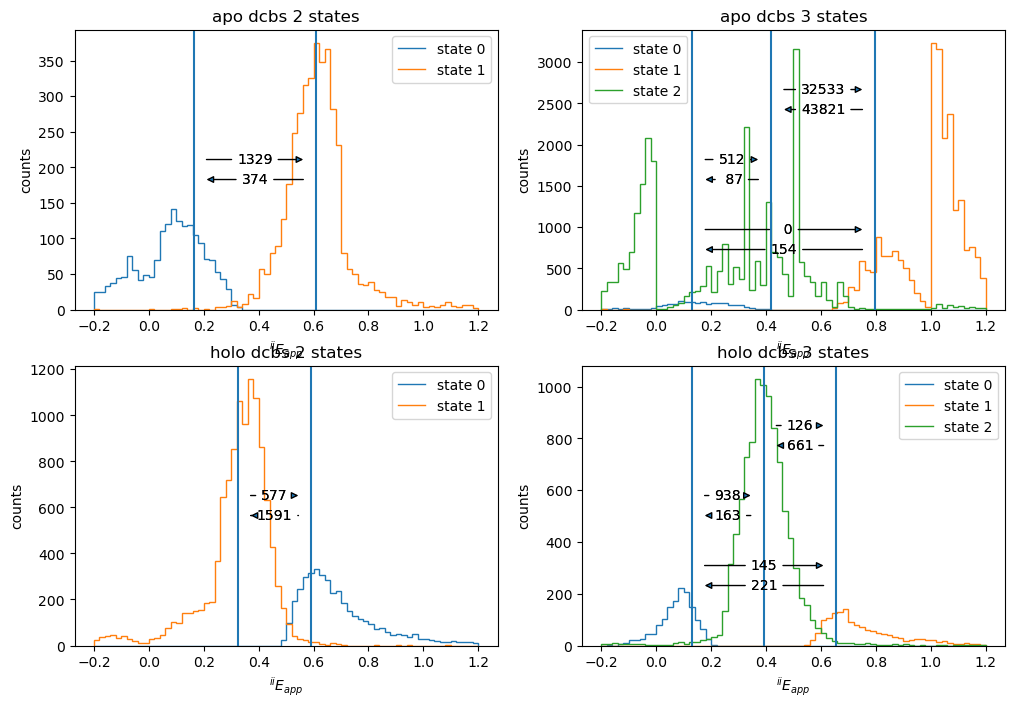

In [22]:
kf = '%s.dcbs.sp'
states = {'apo':(2, 3), 'holo':(2,3)} # states to check

ml = max(len(val) for val in states.values())
fig, ax = plt.subplots(len(datas), ml, figsize=(6*ml, 4*len(datas)))

for i, (key, data) in enumerate(datas.items()):
    k = kf % key
    for j, state in enumerate(states[key]):
        for s in range(state):
            g = smf.make_isin_gate(dwells[k][state-1]['State'], s)
            smf.plot.hist_stair(data, dwells[k][state-1]['E_bg'], 
                                gate=g, ax=ax[i,j],
                                bins=smf.fretfactory.ALEXdefaults['ratio_bins'],
                                label=f'state {s}')
        bhm.plot.hist_model(dwells[k][state-1]['E_raw'], data=data, ax=ax[i,j])
        bhm.plot.hist_model_trans_arrows(dwells[k][state-1]['E_raw'], data=data, ax=ax[i,j])
        ax[i,j].legend()
        ax[i,j].set_title(f'{key} dcbs {state} states')

Again we fill out our choices of ideal models, and give names and order to the states

In [23]:
statesel['apo.dcbs.sp'] = 3
statesel['holo.dcbs.sp'] = 3
names['apo.dcbs.sp'] = ['donor only', 'closed', 'open']
names['holo.dcbs.sp'] = ['donor only', 'closed', 'open']
orders['apo.dcbs.sp'] = [2, 1, 0]
orders['holo.dcbs.sp'] = [2, 1, 0]

### Multi-Parameter with shift $\mathrm{H^{2}MM}$

#### The problem with $\mathrm{\mu sALEX}$

multiparamter $\mathrm{H2MM}$ with $\mathrm{\mu sALEX}$ runs into problems because of the alternation period.
This period results in "clusters" of donor excitation and acceptor excitation photons.

(138355.0, 138355.5)

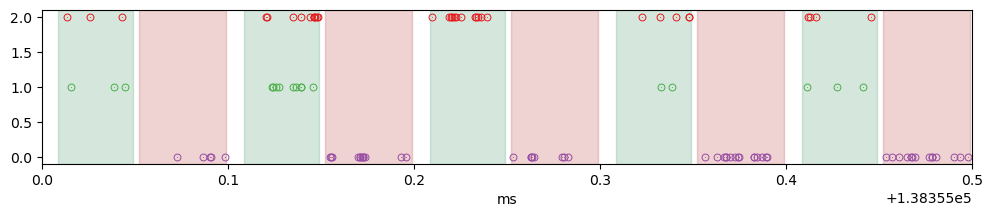

In [24]:
burst_num = 107
bparam = acbs['bursts'].regate(gacbs_fret)

det_pos = {smf.PhSel('0ex0em'):1.0, 
           smf.PhSel('0ex1em'):2.0, 
           smf.PhSel('1ex1em'):0.0}
det_kwargs = {smf.PhSel('0ex0em'):{'c':'#4daf4a'}, 
              smf.PhSel('0ex1em'):{'c':'#e41a1c'}, 
              smf.PhSel('1ex1em'):{'c':'#984ea3'}}

ex_clrs = ['seagreen', 'firebrick']
span_kwargs = [{'color':c} for c in ex_clrs]
alt_span_kwargs = {'alpha':0.2, 'span_kwargs':span_kwargs}

fig, ax = plt.subplots(figsize=(12,2))
smf.plot.burst_dets(datas['apo'].datas[0], bparam, burst_num,
                    det_pos=det_pos, det_kwargs=det_kwargs,
                    linewidths=5.0, s=0.5, zerostart=False, rescale=-3, ax=ax,
                    alt_span=True, alt_span_kwargs=alt_span_kwargs)

# zoom in on 0.5 ms range
ax.set_xlim([138355, 138355.5])

In [25]:
nstreams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
statepath_noshift = bhm.StatePath.optimize(data, bparam,
                                           bhm.factory_h2mm_model(3,3),
                                           streams=nstreams, 
                                           gate=gacbs_fret)

The model converged after 503 iterations


#### Visualizing the problem

(138355.0, 138355.5)

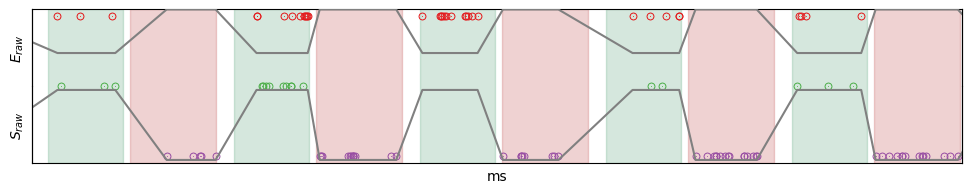

In [26]:
fig = plt.figure(figsize=(12,2))
gs = mpl.gridspec.GridSpec(2,1, figure=fig, hspace=0.0, wspace=0.0)
ax = fig.add_subplot(gs[:,:])
ax.set_yticks([])
axe = fig.add_subplot(gs[0,:], sharex=ax)
axs = fig.add_subplot(gs[1,:], sharex=ax)
for axt in (axe, axs):
    axt.patch.set_alpha(0.0)
    axt.spines[['top','bottom']].set_visible(False)
    axt.set_xticks([])
    axt.set_yticks([])
    axe.set_ylim([0,1])

index_pos={0:1.0, 1:2.0, 2:0.0}
index_kwargs = {0:{'c':'#4daf4a'}, 1:{'c':'#e41a1c'}, 2:{'c':'#984ea3'}}

smf.plot.burst_dets(datas['apo'].datas[0], bparam, burst_num,
                    det_pos=det_pos, det_kwargs=det_kwargs,
                    linewidths=5.0, s=0.5, zerostart=False, rescale=-3, ax=ax,
                    alt_span=True, alt_span_kwargs=alt_span_kwargs)

# get positions of E and S per state 
# to fill out positions for states in statepath
epos, spos = statepath_noshift.model_values(acbs['E_raw'], acbs['S_raw'], 
                                            origin=datas['apo'].datas[0])
epos[~np.isfinite(epos)] = 1.0
spos[~np.isfinite(spos)] = 0.0
# plot E-wise statepath
bhm.plot.burst_statepath(datas['apo'].datas[0], statepath_noshift, burst_num, 
                         ax=axe, slabel='$E_{raw}$', tlabel=False,
                         state_pos=epos, rescale=-3,
                         color='grey')
# plot S-wise statepath
bhm.plot.burst_statepath(datas['apo'].datas[0], statepath_noshift, burst_num, 
                         ax=axs, slabel='$S_{raw}$', tlabel=False,
                         state_pos=spos, rescale=-3,
                         color='grey')

ax.set_xlim([138355, 138355.5])

#### The shift method

To incorporate the acceptor stream into the processing,
some way of stopping the alternation pattern from being present must be added.

The way proposed is to shift the acceptor excitation photons into an adjacent donor excitation period.
Note that this means changing the times and order of the photons.
This is less ideal, but allows detection of changes in acceptor intensity.

H2MMbursts intoduced a number of options for shifting.
Each stream must have a "shift-style" specified, in the shifts parameter.
If no shift is to be applied, (ie Donor stream, the streams of most interest),
the shift should be `"base"`.
For streams that are to be shifted into a given alternation period,
a more complicated stream shift needs to be specified.
In the example below, we specify `"neven:0"`.
There are 3 parts: 
<font color="blue">n</font><font color="red">even</font><font color="magenta">:0</font>

The first can be either "<font color="blue">n</font>" or "<font color="blue">c</font>"
for nearest or contiguous.
Nearest means that photons are shifted by the least amount possible,
while contiguous means that all photons from a given period are all shifted to the same destination period.

The second can be "<font color="red">even</font>", "<font color="red">rand0x\[hex\]</font> " or "<font color="red">shift</font> "
- even means the photons are distributed evenly in their destination period,
- rand means that the photons are randomly distributed in their desitnation period,
  the \[hex\] is a hexidecimal seed for the random number generator.
  e.g. rand0xf2
- shift means that a constant shift is applied to all photons

In general the even shift is recomended, as it is reproducible, and ensures no "bunching" of photons.

The final number (after the colon) is the "destination" excitation period, it should be the same as those of streams labeled "base".

In [27]:
nshifts = ('base', 'base', 'neven:0')
sp_shift_dummy = smf.Param(bhm.usAlexStatePath, 
                           model=bhm.factory_h2mm_model(3,3),
                           streams=nstreams, shifts=nshifts,
                           bursts=bparam)

Lets see how these photons are redistributed.
To see this, we can use the function `bhm.plot.burst_index()`
This function behaves a lot like `smf.plot.burst_dets()`, but expects a 
`bhm.StatePath`, `bhm.usAlexStatePath` or `bhm.ntdivStatePath` 
(the latter as subclasses of `bhm.StatePath`, so we can say a `bhm.StatePath`-like")
based param.

The `det_pos` and `det_kwargs` with `index_pos` and `index_kwargs`.
These are still supplied as dictionaries, 
note that the keys are now integers instead of `smf.PhSel`.

(138355.0, 138355.5)

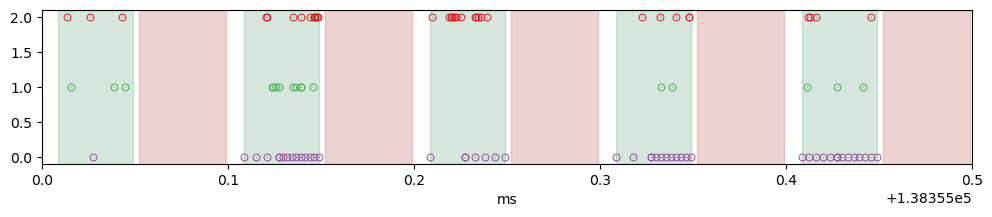

In [28]:
fig, ax = plt.subplots(figsize=(12,2))

bhm.plot.burst_index(datas['apo'].datas[0], sp_shift_dummy, burst_num,
                     index_pos=index_pos, index_kwargs=index_kwargs,
                     linewidths=5.0, s=0.5, rescale=-3, ax=ax,
                     alt_span=True, alt_span_kwargs=alt_span_kwargs)

ax.set_xlim([138355, 138355.5])

#### $\mathrm{mpH^{2}MM}$ with shift optimization
So, now lets optimize multiparameter models with shifts:

In [29]:
mpstreams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
mpshifts = ('base', 'base', 'neven:0')

for key, data in datas.items():
    k = f'{key}.acbs.mp'
    statepaths[k] = bhm.usAlexStatePath.optimize_models(data, acbs['bursts'], gate=gacbs_fret,
                                                        streams=mpstreams, shifts=mpshifts,
                                                        conv_crit='BICph', thresh=0.005)
    # generate dwell based parameters/columns
    dwells[k] = [bhm.fretfactory.make_dwell_dict(statepath) for statepath in statepaths[k]]

    # optimize dcbs selection
    k = f'{key}.dcbs.mp'
    statepaths[k] = bhm.usAlexStatePath.optimize_models(data, dcbs['bursts'], gate=gdcbs,
                                                        streams=mpstreams, shifts=mpshifts,
                                                        conv_crit='BICph', thresh=0.005)
    # generate dwell based parameters/columns
    dwells[k] = [bhm.fretfactory.make_dwell_dict(statepath) for statepath in statepaths[k]]

The model converged after 1 iterations
The model converged after 84 iterations
The model converged after 1193 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
The model converged after 1 iterations
The model converged after 86 iterations
The model converged after 684 iterations
The model converged after 1358 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
The model converged after 3 iterations
The model converged after 63 iterations
The model converged after 395 iterations
The model converged after 348 iterations
The model converged after 1333 iterations
The model converged after 1287 iterations
The model converged after 1 iterations
The model converged after 83 iterations
The model converged after 325 iterations
The model converged after 274 iterations
The model converged after 794 iterations
Optimization reached

As before, let's plot the statistical discriminators:

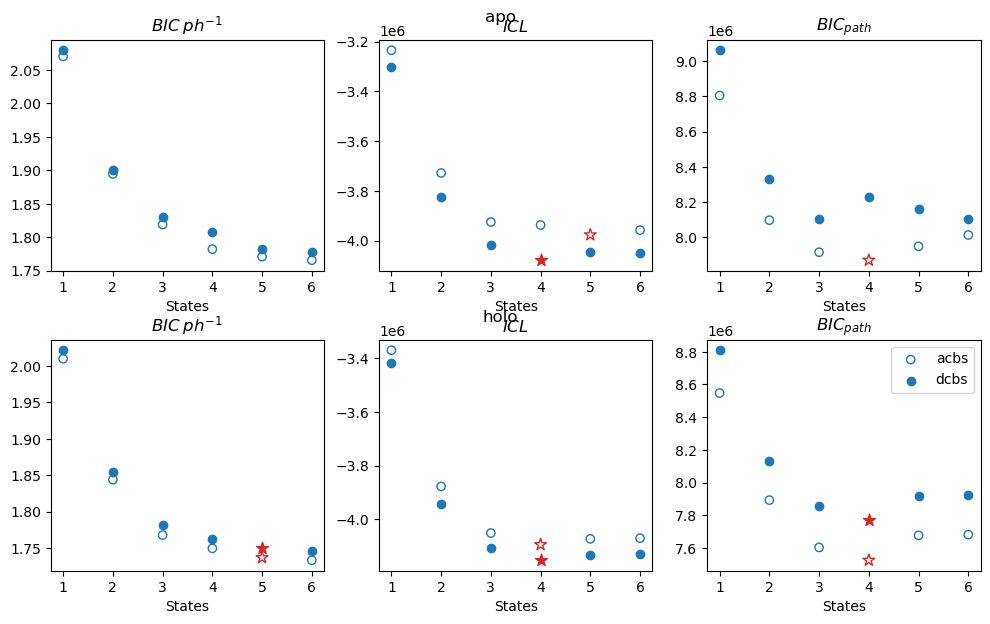

In [30]:
fig = plt.figure(figsize=(12, 3*len(datas)))
subfigs = fig.subfigures(len(datas),1)

for sfig, key in zip(subfigs, datas.keys()):
    ax = sfig.subplots(1,3)
    # plot acbs
    k = f'{key}.acbs.mp'
    statepath = statepaths[k]
    bhm.plot.scatter_BICph(data, statepath, ax=ax[0], thresh=0.005, **acbs_kwargs)
    bhm.plot.scatter_ICL(data, statepath, ax=ax[1], **acbs_kwargs)
    bhm.plot.scatter_pathBIC(data, statepath, ax=ax[2], label='acbs', **acbs_kwargs)
    # plot dcbs
    k = f'{key}.dcbs.mp'
    statepath = statepaths[k]
    bhm.plot.scatter_BICph(data, statepath, ax=ax[0], thresh=0.005, **dcbs_kwargs)
    bhm.plot.scatter_ICL(data, statepath, ax=ax[1], **dcbs_kwargs)
    bhm.plot.scatter_pathBIC(data, statepath, ax=ax[2], label='dcbs', **dcbs_kwargs)
    sfig.suptitle(key)
ax[-1].legend()

We can also see how the statepath no longer detects the alternation period:

(138355.0, 138355.5)

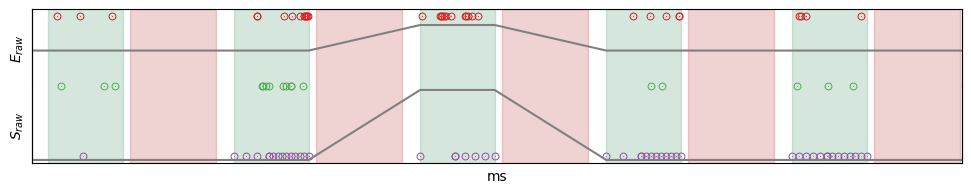

In [31]:
fig = plt.figure(figsize=(12,2))
gs = mpl.gridspec.GridSpec(2,1, figure=fig, hspace=0.0, wspace=0.0)
ax = fig.add_subplot(gs[:,:])
ax.set_yticks([])
axe = fig.add_subplot(gs[0,:], sharex=ax)
axs = fig.add_subplot(gs[1,:], sharex=ax)
for axt in (axe, axs):
    axt.patch.set_alpha(0.0)
    axt.spines[['top','bottom']].set_visible(False)
    axt.set_xticks([])
    axt.set_yticks([])
    axe.set_ylim([0,1])


bhm.plot.burst_index(datas['apo'].datas[0], statepaths['apo.acbs.mp'][3], 
                     burst_num, index_pos=index_pos, index_kwargs=index_kwargs,
                    linewidths=5.0, s=0.5, zerostart=False, rescale=-3, ax=ax,
                    alt_span=True, alt_span_kwargs=alt_span_kwargs)



epos, spos = statepaths['apo.acbs.mp'][3].model_values(acbs['E_raw'], 
                                                       acbs['S_raw'], 
                                                       origin=datas['apo'])
epos[~np.isfinite(epos)] = 1.0
spos[~np.isfinite(spos)] = 0.0
bhm.plot.burst_statepath(datas['apo'].datas[0], statepaths['apo.acbs.mp'][3], 
                         burst_num, ax=axe, slabel='$E_{raw}$', tlabel=False,
                         state_pos=epos, rescale=-3, color='grey')

bhm.plot.burst_statepath(datas['apo'].datas[0], statepaths['apo.acbs.mp'][3],
                         burst_num, ax=axs, slabel='$S_{raw}$', tlabel=False,
                         state_pos=spos, rescale=-3, color='grey')

ax.set_xlim([138355, 138355.5])

#### multiparameter ACBS state visualization/selection

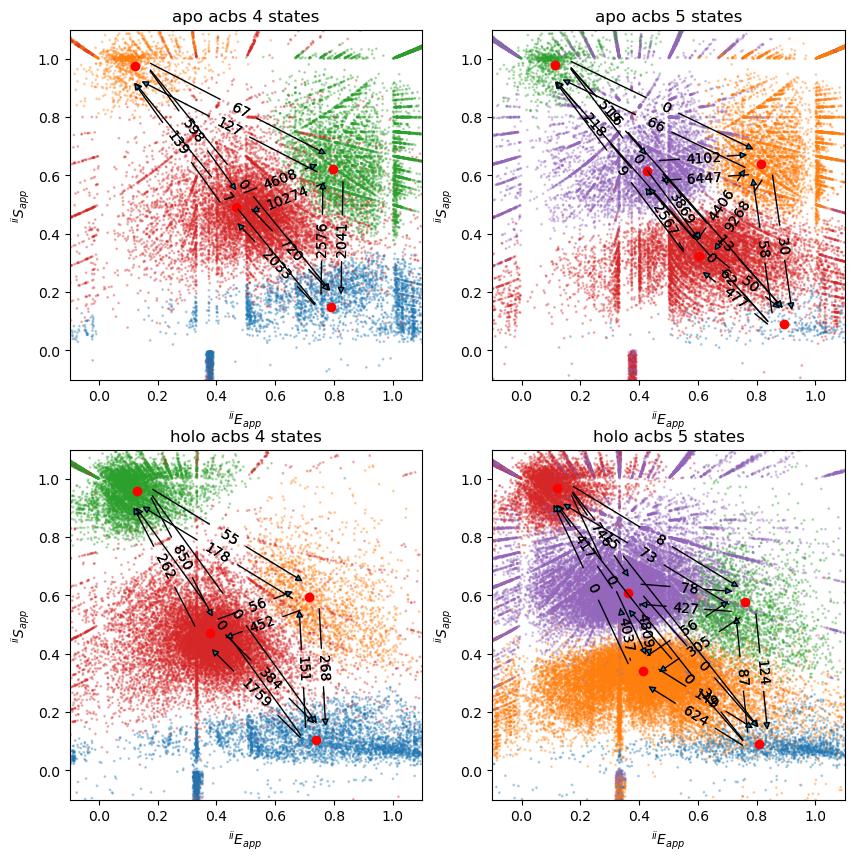

In [32]:
kf = '%s.acbs.mp'
states = {'apo':(4, 5), 'holo':(4,5)} # states to check

ml = max(len(val) for val in states.values())
fig, ax = plt.subplots(len(datas), ml, figsize=(5*ml, 5*len(datas)))

for i, (key, data) in enumerate(datas.items()):
    for j, state in enumerate(states[key]):
        kn = kf % key
        smf.plot.scatter(data, dwells[kn][state-1]['E_bg'], 
                         dwells[kn][state-1]['S_bg'], 
                         point_func=smf.plot.colorcategory,
                         point_cols=dwells[kn][state-1]['State'],
                         point_kwargs={'cmap':mpl.colormaps['tab10']},
                         ax=ax[i,j], s=1.0, alpha=0.3)
        bhm.plot.scatter_model(dwells[kn][state-1]['E_bg'], 
                               dwells[kn][state-1]['S_bg'], 
                               statepath=statepaths[kn][state-1], 
                               data=data, ax=ax[i,j], c='r')

        bhm.plot.scatter_model_trans_arrows(acbs['E_raw'], acbs['S_raw'],
                                            statepath=statepaths[kn][state-1],
                                            data=data, ax=ax[i,j])
        ax[i,j].set_title(f'{key} acbs {state} states')
        ax[i,j].set_xlim([-0.1, 1.1])
        ax[i,j].set_ylim([-0.1, 1.1])

Here, using the acbs bursts $\mathbf{H^{2}MM}$, the holo is almost certainly the correct choice.
For the apo, the 5 state model looks somewhat reasonable a s fit, but the physical interpretation is much more unclear.
Therefore we will choose the 4 state models for both.

In [33]:
statesel['apo.acbs.mp'] = 4
statesel['holo.acbs.mp'] = 4
names['apo.acbs.mp'] = ['acceptor only', 'donor only', 'closed', 'open']
names['holo.acbs.mp'] = ['acceptor only', 'closed', 'donor only', 'open']
orders['apo.acbs.mp'] = [3,2,0,1]
orders['holo.acbs.mp'] = [3,1,3,0]

#### multiparameter DCBS state visualization/selection

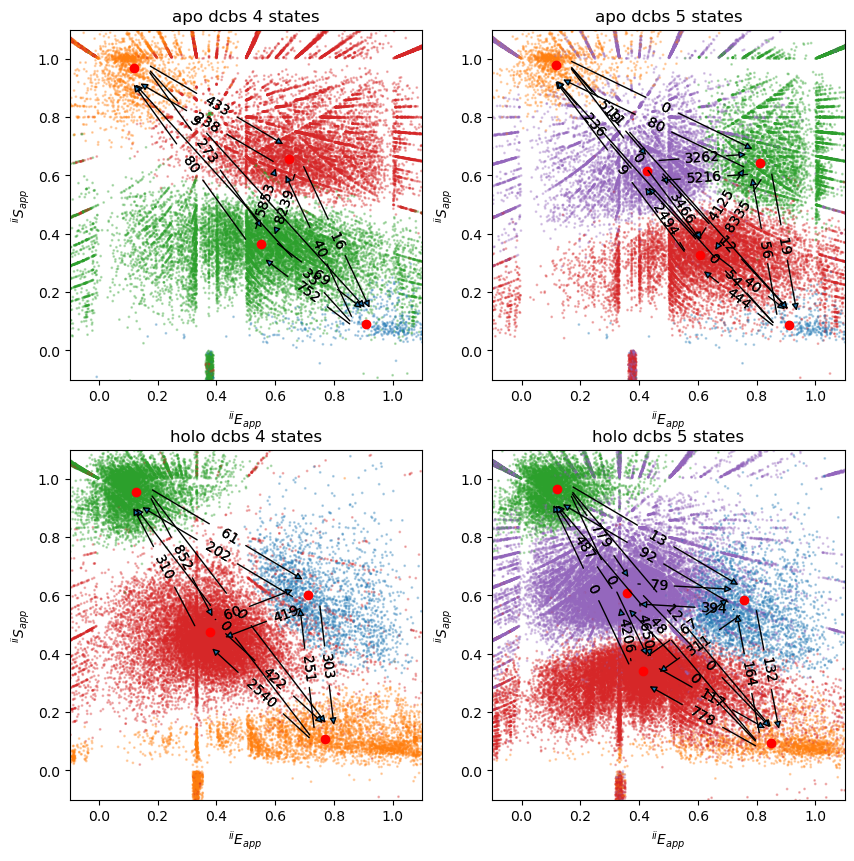

In [34]:
kf = '%s.dcbs.mp'
states = {'apo':(4, 5), 'holo':(4,5)} # states to check

ml = max(len(val) for val in states.values())
fig, ax = plt.subplots(len(datas), ml, figsize=(5*ml, 5*len(datas)))

for i, (key, data) in enumerate(datas.items()):
    for j, state in enumerate(states[key]):
        kn = kf % key
        smf.plot.scatter(data, dwells[kn][state-1]['E_bg'], 
                         dwells[kn][state-1]['S_bg'], 
                         point_func=smf.plot.colorcategory,
                         point_cols=dwells[kn][state-1]['State'],
                         point_kwargs={'cmap':mpl.colormaps['tab10']},
                         ax=ax[i,j], s=1.0, alpha=0.3)
        bhm.plot.scatter_model(dwells[kn][state-1]['E_bg'], 
                               dwells[kn][state-1]['S_bg'], 
                               statepath=statepaths[kn][state-1], 
                               data=data, ax=ax[i,j], c='r')

        bhm.plot.scatter_model_trans_arrows(acbs['E_raw'], acbs['S_raw'],
                                            statepath=statepaths[kn][state-1],
                                            data=data, ax=ax[i,j])
        ax[i,j].set_title(f'{key} dcbs {state} states')
        ax[i,j].set_xlim([-0.1, 1.1])
        ax[i,j].set_ylim([-0.1, 1.1])

The DCBS results are similar,
while the 5 state models, epecailly for the apo condition has some merits,
Overall, the 4 state models are a better fit, so we will build state-name and order arrays accordingly.

In [35]:
statesel['apo.dcbs.mp'] = 4
statesel['holo.dcbs.mp'] = 4
names['apo.dcbs.mp'] = ['acceptor only', 'donor only', 'closed', 'open']
names['holo.dcbs.mp'] = ['closed', 'acceptor only', 'donor only', 'open']
orders['apo.dcbs.mp'] = [3,2,1,0]
orders['holo.dcbs.mp'] = [1,3,2,0]

In [36]:
bcmap = dict()
dcmap = dict()
nlist = dict()

for key in statesel.keys():
    temp = bhm.plot.make_bstate_cmap(names[key], mpl.colormaps['tab10'].colors, 
                                     order=orders[key])
    bcmap[key], dcmap[key], nlist[key] = temp

### Examining ideal models

Text(0.5, 0.98, 'acbs')

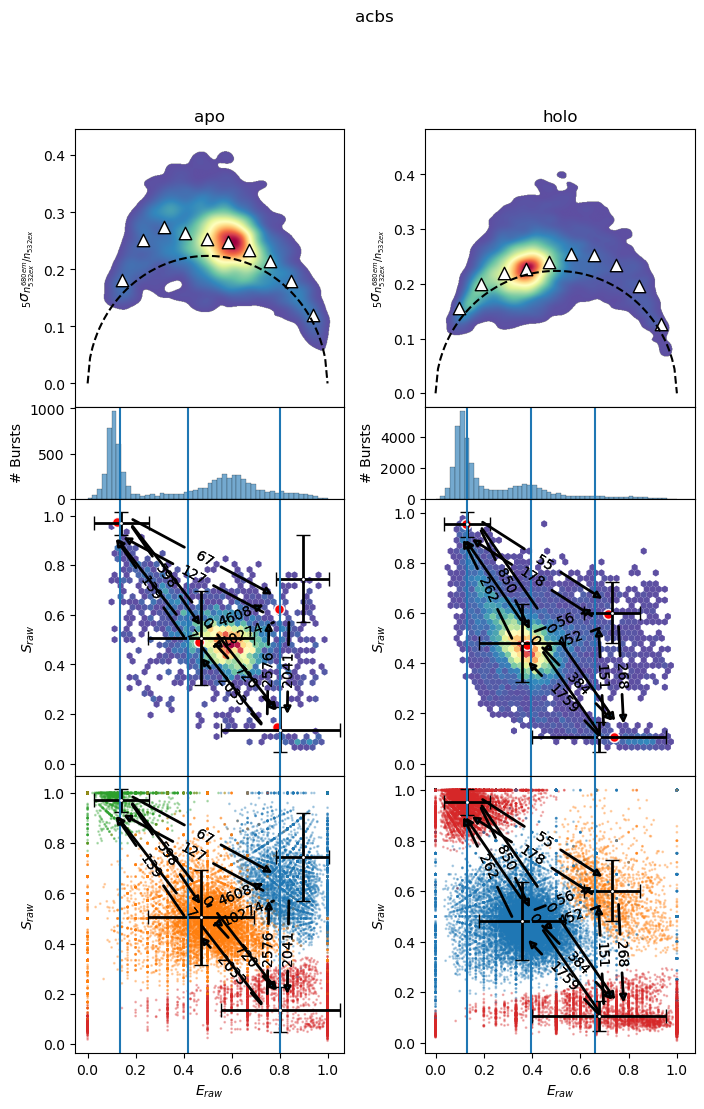

In [37]:
bsel = 'acbs'
# arrays for default static BVA line
x_t = np.linspace(0,1,100)
y_t = np.sqrt((1-x_t)*x_t/nbva)

fig = plt.figure(figsize=(4*len(datas),12))
gs = mpl.gridspec.GridSpec(ncols=len(datas), nrows=10, figure=fig,
                           wspace=0.3, hspace=0.0)

scatt_kw = dict(color='r',marker='o', lw=1.0, ec='white', s=50.0, alpha=0.85)
tarrow_kw = dict(arrowprops={'ec':'k', 'lw':2})
ebar_kw = dict(color='k', lw=0, ms=2, marker='.', elinewidth=2, capsize=5, 
               mec='white', mew=1, xlabel=False, ylabel=False)

for i, (key, data) in enumerate(datas.items()):
    ks = f'{key}.{bsel}.sp'
    km = f'{key}.{bsel}.mp'
    axs = [fig.add_subplot(gs[0:3,i]), ] # BVA plot
    axs.append(fig.add_subplot(gs[3,i],sharex=axs[0]))
    axs.append(fig.add_subplot(gs[4:7,i],sharex=axs[0]))
    axs.append(fig.add_subplot(gs[7:10,i],sharex=axs[0]))
    # BVA plot
    smf.plot.kdeplot(data, acbs['E_raw'], acbs[f'BVA{nbva}'], 
                     ax=axs[0], gate=gacbs_fret, 
                     cmap='Spectral_r', thresh=0.01, xlabel=False)
    smf.plot.scatter_meaninterval(data, acbs['E_raw'], acbs[f'BVA{nbva}'],
                                  gate=gacbs_fret, ax=axs[0], xlabel=False,
                                  marker='^', c='w', ec='k', s=80)
    axs[0].plot(x_t, y_t, c='k', ls='--')
    # E hist
    smf.plot.hist_bar(data, acbs['E_raw'], ax=axs[1], xlabel=False,
                      **smf.fretfactory.ALEXdefaults['histbar',('bins','raw_ratio_bins')])
    # Hexbin
    smf.plot.hexbin(data, acbs['E_raw'], acbs['S_raw'], gate=gacbs_fret,
                    ax=axs[2], xlabel=False, cmap='Spectral_r',
                    **smf.fretfactory.ALEXdefaults['hexbinraw'])
    # dwells
    smf.plot.scatter(data, dwells[km][statesel[km]-1]['E_raw'], 
                     dwells[km][statesel[km]-1]['S_raw'],
                     point_func=smf.plot.colorcategory,
                     point_cols=dwells[km][statesel[km]-1]['State'],
                     point_kwargs={'cmap':bcmap[km]}, s=1.0, alpha=0.3,
                     ax=axs[3])
    # transion rate arrow/plots
    for ax in axs[2:]:
        bhm.plot.scatter_model(acbs['E_raw'], acbs['S_raw'], 
                               statepath=statepaths[km][statesel[km]-1],
                               data=data, ax=axs[2], **scatt_kw)
        bhm.plot.scatter_model_trans_arrows(acbs['E_raw'], acbs['S_raw'], data=data,
                                            statepath=statepaths[km][statesel[km]-1],
                                            ax=ax, **tarrow_kw)
        smf.plot.errorbars(data, dwells[km][statesel[km]-1]['E_raw'], 
                           dwells[km][statesel[km]-1]['S_raw'],
                           dwells[km][statesel[km]-1]['State'], 
                           ax=ax, **ebar_kw)

    for ax in axs[1:]:
        bhm.plot.hist_model(acbs['E_raw'], data=data, ax=ax,
                            statepath=statepaths[ks][statesel[ks]-1])
    axs[0].set_title(key)
fig.suptitle(bsel)

Text(0.5, 0.98, 'dcbs')

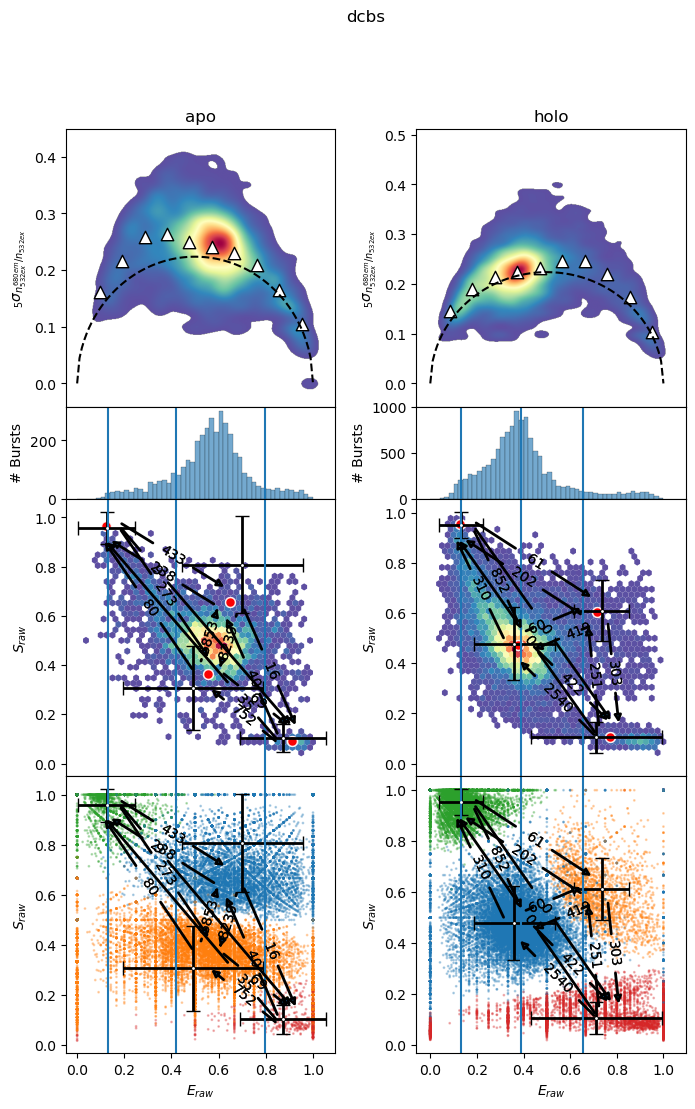

In [38]:
bsel = 'dcbs'
# arrays for default static BVA line
x_t = np.linspace(0,1,100)
y_t = np.sqrt((1-x_t)*x_t/nbva)

fig = plt.figure(figsize=(4*len(datas),12))
gs = mpl.gridspec.GridSpec(ncols=len(datas), nrows=10, figure=fig,
                           wspace=0.3, hspace=0.0)

scatt_kw = dict(color='r',marker='o', lw=1.0, ec='white', s=50.0, alpha=0.85)
tarrow_kw = dict(arrowprops={'ec':'k', 'lw':2})
ebar_kw = dict(color='k', lw=0, ms=2, marker='.', elinewidth=2, capsize=5, 
               mec='white', mew=1, xlabel=False, ylabel=False)

for i, (key, data) in enumerate(datas.items()):
    ks = f'{key}.{bsel}.sp'
    km = f'{key}.{bsel}.mp'
    axs = [fig.add_subplot(gs[0:3,i]), ] # BVA plot
    axs.append(fig.add_subplot(gs[3,i],sharex=axs[0]))
    axs.append(fig.add_subplot(gs[4:7,i],sharex=axs[0]))
    axs.append(fig.add_subplot(gs[7:10,i],sharex=axs[0]))
    # BVA plot
    smf.plot.kdeplot(data, dcbs['E_raw'], dcbs[f'BVA{nbva}'], 
                     ax=axs[0], gate=gdcbs, 
                     cmap='Spectral_r', thresh=0.01, xlabel=False)
    smf.plot.scatter_meaninterval(data, dcbs['E_raw'], dcbs[f'BVA{nbva}'],
                                  gate=gdcbs, ax=axs[0], xlabel=False,
                                  marker='^', c='w', ec='k', s=80)
    axs[0].plot(x_t, y_t, c='k', ls='--')
    # E hist
    smf.plot.hist_bar(data, dcbs['E_raw'], ax=axs[1], xlabel=False,
                      **smf.fretfactory.ALEXdefaults['histbar',('bins','raw_ratio_bins')])
    # Hexbin
    smf.plot.hexbin(data, dcbs['E_raw'], dcbs['S_raw'], gate=gdcbs,
                    ax=axs[2], xlabel=False, cmap='Spectral_r',
                    **smf.fretfactory.ALEXdefaults['hexbinraw'])
    # dwells
    smf.plot.scatter(data, dwells[km][statesel[km]-1]['E_raw'], 
                     dwells[km][statesel[km]-1]['S_raw'],
                     point_func=smf.plot.colorcategory,
                     point_cols=dwells[km][statesel[km]-1]['State'],
                     point_kwargs={'cmap':bcmap[km]}, s=1.0, alpha=0.3,
                     ax=axs[3])
    # transion rate arrow/plots
    for ax in axs[2:]:
        bhm.plot.scatter_model(dcbs['E_raw'], dcbs['S_raw'], 
                               statepath=statepaths[km][statesel[km]-1],
                               data=data, ax=axs[2], **scatt_kw)
        bhm.plot.scatter_model_trans_arrows(dcbs['E_raw'], dcbs['S_raw'], data=data,
                                            statepath=statepaths[km][statesel[km]-1],
                                            ax=ax, **tarrow_kw)
        smf.plot.errorbars(data, dwells[km][statesel[km]-1]['E_raw'], 
                           dwells[km][statesel[km]-1]['S_raw'],
                           dwells[km][statesel[km]-1]['State'], 
                           ax=ax, **ebar_kw)

    for ax in axs[1:]:
        bhm.plot.hist_model(dcbs['E_raw'], data=data, ax=ax,
                            statepath=statepaths[ks][statesel[ks]-1])
    axs[0].set_title(key)
fig.suptitle(bsel)

End of notebook